In [23]:
import pandas as pd
import numpy as np

# Đọc tập dữ liệu
# Giả sử file của bạn tên là 'credit_risk_dataset_5c.csv'
df = pd.read_csv('credit_risk_dataset_5c.csv')

# Không dùng addr_state trong pipeline này
df = df.drop(columns=['addr_state'], errors='ignore')

print(f"Số lượng dòng ban đầu: {df.shape}")


Số lượng dòng ban đầu: (1277409, 12)


In [24]:
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": df.isnull().mean() * 100
})

print(missing)

                     Missing Count  Missing %
pub_rec                          0        0.0
num_tl_90g_dpd_24m               0        0.0
annual_inc                       0        0.0
dti                              0        0.0
loan_amnt                        0        0.0
term                             0        0.0
tot_cur_bal                      0        0.0
home_ownership                   0        0.0
purpose                          0        0.0
verification_status              0        0.0
addr_state                       0        0.0
label                            0        0.0


In [25]:
# ==============================
# Group rare categories (fit trên train, apply cho test)
# ==============================

def apply_grouping(df, home_keep, purpose_keep):
    out = df.copy()
    out['home_ownership'] = out['home_ownership'].apply(
        lambda x: x if x in home_keep else 'OTHER'
    )
    out['purpose'] = out['purpose'].apply(
        lambda x: x if x in purpose_keep else 'OTHER'
    )
    return out


=== home_ownership after grouping ===
home_ownership
MORTGAGE    635368
RENT        502111
OWN         139554
OTHER          376
Name: count, dtype: int64

=== purpose after grouping ===
purpose
debt_consolidation    746188
credit_card           284896
OTHER                 163514
home_improvement       82811
Name: count, dtype: int64


In [26]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['label'])
y = df['label']

# Chia tập dữ liệu thành 80% Train và 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
print(f"Số lượng dòng tập Train: {X_train.shape[0]:,}")
print(f"Số lượng dòng tập Test: {X_test.shape[0]:,}")

train_df = X_train.copy()
train_df['label'] = y_train
test_df = X_test.copy()
test_df['label'] = y_test

# Fit grouping rules từ train
home_keep = ['MORTGAGE', 'RENT', 'OWN']
purpose_keep = ['debt_consolidation', 'credit_card', 'home_improvement']

train_df = apply_grouping(train_df, home_keep, purpose_keep)
test_df = apply_grouping(test_df, home_keep, purpose_keep)

print("=== home_ownership after grouping (train) ===")
print(train_df['home_ownership'].value_counts(dropna=False))
print()
print("=== purpose after grouping (train) ===")
print(train_df['purpose'].value_counts(dropna=False))


Số lượng dòng tập Train: 1,021,927
Số lượng dòng tập Test: 255,482


In [27]:
# =====================================================================
# Bước 1: HÀM LÀM SẠCH LOGIC - XÓA CÁC GIÁ TRỊ BẤT HỢP LÝ
# =====================================================================
def clean_logic_numerical(df):
    """
    Xóa các dòng có giá trị không hợp logic nghiệp vụ.
    """
    # Xóa annual_inc <= 0, dti < 0, tot_cur_bal < 0
    df_cleaned = df[
        (df['annual_inc'] > 0) & 
        (df['dti'] >= 0) & 
        (df['tot_cur_bal'] >= 0)&
        (df['pub_rec'] >= 0) &
        (df['num_tl_90g_dpd_24m'] >= 0)&
        (df['loan_amnt'] > 0)
    ].copy()
    return df_cleaned.reset_index(drop=True)

# Áp dụng làm sạch cho cả tập Train và Test
train_df = clean_logic_numerical(train_df)
test_df = clean_logic_numerical(test_df)

print(f"Kích thước Train sau làm sạch: {train_df.shape}")
print(f"Kích thước Test sau làm sạch: {test_df.shape}")

print("\nPhân bố nhãn sau clean - Train:")
print(train_df['label'].value_counts(normalize=True).sort_index())
print("Phân bố nhãn sau clean - Test:")
print(test_df['label'].value_counts(normalize=True).sort_index())


Kích thước Train sau làm sạch: (1021925, 12)
Kích thước Test sau làm sạch: (255482, 12)


In [28]:
def feature_engineering(df):
    """
    Hàm thực hiện Feature Engineering tạo ra các biến mới dựa trên Business Rules và thực tế dữ liệu.
    """
    # Tạo bản sao để không làm thay đổi DataFrame gốc
    df_eng = df.copy()

    # =====================================================================
    # 1. TẠO BIẾN TỶ LỆ (RATIOS)
    # =====================================================================
    # LTI (Loan-to-Income): Gánh nặng khoản vay so với thu nhập
    df_eng['LTI'] = df_eng['loan_amnt'] / df_eng['annual_inc']

    # =====================================================================
    # 2. TẠO CỜ PHÂN LOẠI (BINARY FLAGS) TỪ NGƯỠNG NGHIỆP VỤ
    # =====================================================================
    # Chuyển đổi DTI thành các cờ cảnh báo rủi ro
    df_eng['flag_high_dti'] = (df_eng['dti'] > 35).astype(int)
    df_eng['flag_very_high_dti'] = (df_eng['dti'] > 45).astype(int)

    # =====================================================================
    # 3. NHỊ PHÂN HÓA (BINARIZE) TÍN HIỆU RỦI RO CỰC ĐOAN
    # =====================================================================
    # Chuyển đổi hồ sơ xấu và nợ quá hạn thành cờ Có/Không (1/0)
    df_eng['flag_any_derog'] = (df_eng['pub_rec'] > 0).astype(int)
    df_eng['flag_recent_dpd'] = (df_eng['num_tl_90g_dpd_24m'] > 0).astype(int)

    # =====================================================================
    # 4. BIẾN ĐỔI LOGARIT (LOG TRANSFORM)
    # =====================================================================
    # Giảm độ lệch phải, giúp mô hình ổn định mà không cần cắt bỏ hồ sơ
    df_eng['annual_inc'] = np.log1p(df_eng['annual_inc'])
    df_eng['tot_cur_bal'] = np.log1p(df_eng['tot_cur_bal'])

    # =====================================================================
    # 5. XỬ LÝ KỲ HẠN VÀ TẠO CỜ RỦI RO KỲ HẠN
    # =====================================================================
    # Trích xuất con số từ chuỗi (VD: " 60 months" -> 60)
    df_eng['term_months'] = df_eng['term'].str.extract(r'(\d+)').astype(int)
    # Tạo cờ cho kỳ hạn 60 tháng (Tín hiệu tương quan vỡ nợ mạnh nhất)
    df_eng['term_60'] = (df_eng['term_months'] == 60).astype(int)

   
   
    # (Tùy chọn) Xóa cột 'term' gốc vì đã chuyển thành 'term_months' và 'term_60'
    df_eng = df_eng.drop(columns=['term'])

    return df_eng


train_df = feature_engineering(train_df)
test_df = feature_engineering(test_df)

# Không dùng addr_state trong pipeline này
train_df = train_df.drop(columns=['addr_state'], errors='ignore')
test_df = test_df.drop(columns=['addr_state'], errors='ignore')

 # =====================================================================
    # 6. MÃ HÓA DỮ LIỆU PHÂN LOẠI (CATEGORICAL ENCODING)
    # =====================================================================
    # Lưu ý: Tuyệt đối KHÔNG dùng Ordinal Encoding cho verification_status vì nhóm Verified lại rủi ro cao hơn.
    # Sử dụng One-Hot Encoding (get_dummies) cho các biến chữ.
categorical_cols = ['home_ownership', 'purpose', 'verification_status']
 # drop_first=True giúp tránh bẫy đa cộng tuyến (Dummy Variable Trap)
train_df = pd.get_dummies(train_df, columns=categorical_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=categorical_cols, drop_first=True)

y_train_final = train_df['label'].copy()
y_test_final = test_df['label'].copy()

X_train_final = train_df.drop(columns=['label'])
X_test_final = test_df.drop(columns=['label'])

# ép test theo schema train
X_train_final, X_test_final = X_train_final.align(
    X_test_final, join='left', axis=1, fill_value=0
)

train_df = X_train_final.copy()
train_df['label'] = y_train_final.values

test_df = X_test_final.copy()
test_df['label'] = y_test_final.values
# Xem các tính năng mới được tạo
print(train_df.head())

   pub_rec  num_tl_90g_dpd_24m  annual_inc    dti  loan_amnt  tot_cur_bal  \
0      1.0                 0.0   11.082158   5.21    24700.0    12.383001   
1      0.0                 0.0   11.396403  34.70    21600.0    12.896742   
2      0.0                 0.0   11.082158  16.65     8625.0    10.583803   
3      0.0                 0.0   10.771302  11.74    12000.0    10.842635   
4      0.0                 0.0   11.018646  18.90    12000.0    10.500757   

  addr_state       LTI  flag_high_dti  flag_very_high_dti  ...  term_60  \
0         IL  0.380000              0                   0  ...        0   
1         VA  0.242697              0                   0  ...        1   
2         MD  0.132692              0                   0  ...        0   
3         CO  0.251926              0                   0  ...        1   
4         FL  0.196721              0                   0  ...        0   

   home_ownership_OTHER  home_ownership_OWN  home_ownership_RENT  \
0                 

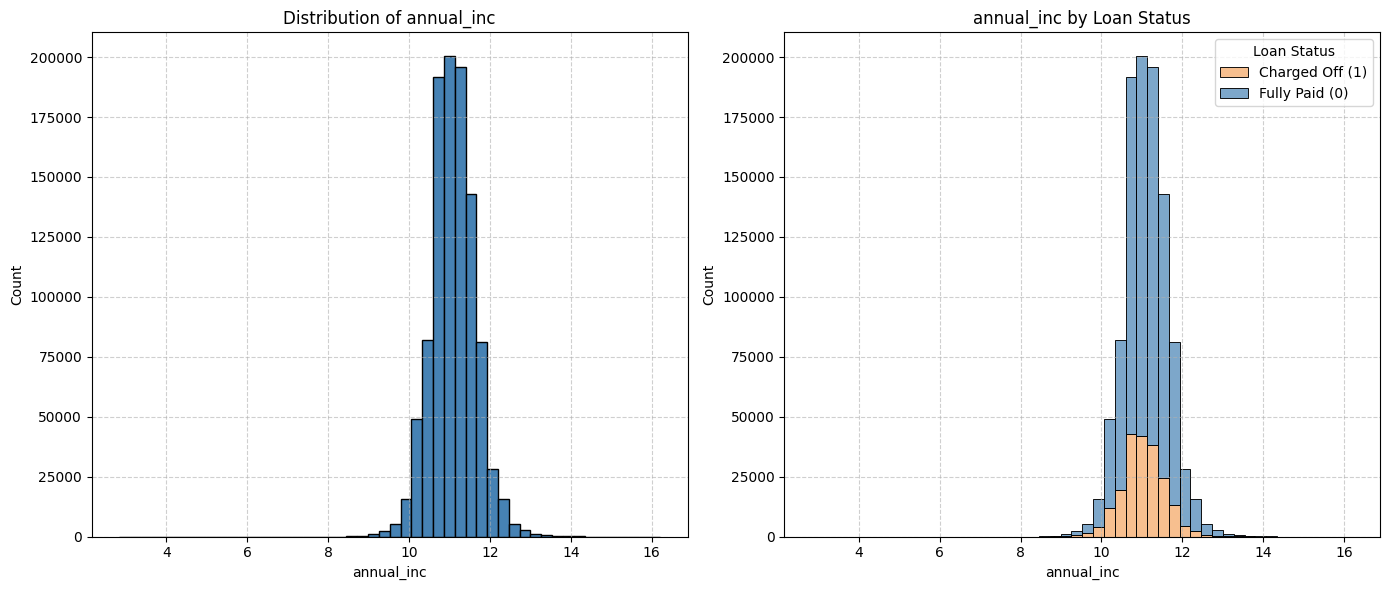

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Thiết lập kích thước khung hình
plt.figure(figsize=(14, 6))

# =======================================================
# Biểu đồ 1: Phân phối tổng thể của annual_inc
# =======================================================
plt.subplot(1, 2, 1)
plt.hist(train_df['annual_inc'], bins=50, color='steelblue', edgecolor='black')
plt.title('Distribution of annual_inc')
plt.xlabel('annual_inc')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.6)

# =======================================================
# Biểu đồ 2: Phân phối annual_inc theo Loan Status (Label)
# =======================================================
plt.subplot(1, 2, 2)
# Nhóm 0 = Fully Paid, Nhóm 1 = Charged Off
sns.histplot(
    data=train_df, 
    x='annual_inc', 
    hue='label', 
    bins=50, 
    multiple='stack', # Chồng 2 nhóm lên nhau để dễ quan sát
    palette={0: 'steelblue', 1: 'sandybrown'}, 
    alpha=0.7
)
plt.title('annual_inc by Loan Status')
plt.xlabel('annual_inc')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Loan Status', labels=['Charged Off (1)', 'Fully Paid (0)'])

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

In [30]:
#  Ghép lại feature và label cho từng tập từ dữ liệu đã xử lý
train_processed = train_df.copy()
test_processed = test_df.copy()

# Tên file
train_file = 'credit_risk_train.csv'
test_file = 'credit_risk_test.csv'

# Xuất file
train_processed.to_csv(train_file, index=False)
test_processed.to_csv(test_file, index=False)

print(f"\n=> Dữ liệu train đã được lưu thành công vào file: {train_file}")
print(f"=> Dữ liệu test đã được lưu thành công vào file: {test_file}")

print("Kích thước train:", train_processed.shape)
print("Kích thước test:", test_processed.shape)


=> Dữ liệu train đã được lưu thành công vào file: credit_risk_train.csv
=> Dữ liệu test đã được lưu thành công vào file: credit_risk_test.csv
Kích thước train: (1021925, 23)
Kích thước test: (255482, 23)
